### Get the Dataset

In [1]:
import os
import tarfile
import urllib.request
import pandas as pd
from pathlib import Path  # FIX 1: Imported Path

def download_and_load_housing_data(
    url="https://github.com/ageron/data/raw/main/housing.tgz", 
    download_dir="datasets"
):
    """
    Downloads a .tgz dataset from the web, extracts it, 
    and loads the resulting CSV into a pandas DataFrame.
    """
    # 1. Create the target directory if it doesn't exist
    os.makedirs(download_dir, exist_ok=True)
    
    # FIX 2: Fixed the string joining typo. 
    # Removed the missing comma/accidental string concatenation ("housing" "housing.tgz")
    tgz_path = os.path.join(download_dir, "housing.tgz")
    
    # 2. Download the compressed file
    print(f"Downloading dataset from {url}...")
    urllib.request.urlretrieve(url, tgz_path)
    
    # 3. Extract the tarball contents
    print("Extracting archive...")
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=download_dir)
        
    # FIX 3: Replaced the hardcoded "datasets" with the download_dir variable
    csv_path = Path(download_dir) / "housing" / "housing.csv"
    print(f"Loading data into DataFrame from {csv_path}...")
    df = pd.read_csv(csv_path)
    
    return df

housing = download_and_load_housing_data()
print(housing.head())

Extracting archive...
Loading data into DataFrame from datasets\housing\housing.csv...
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0       

In [2]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

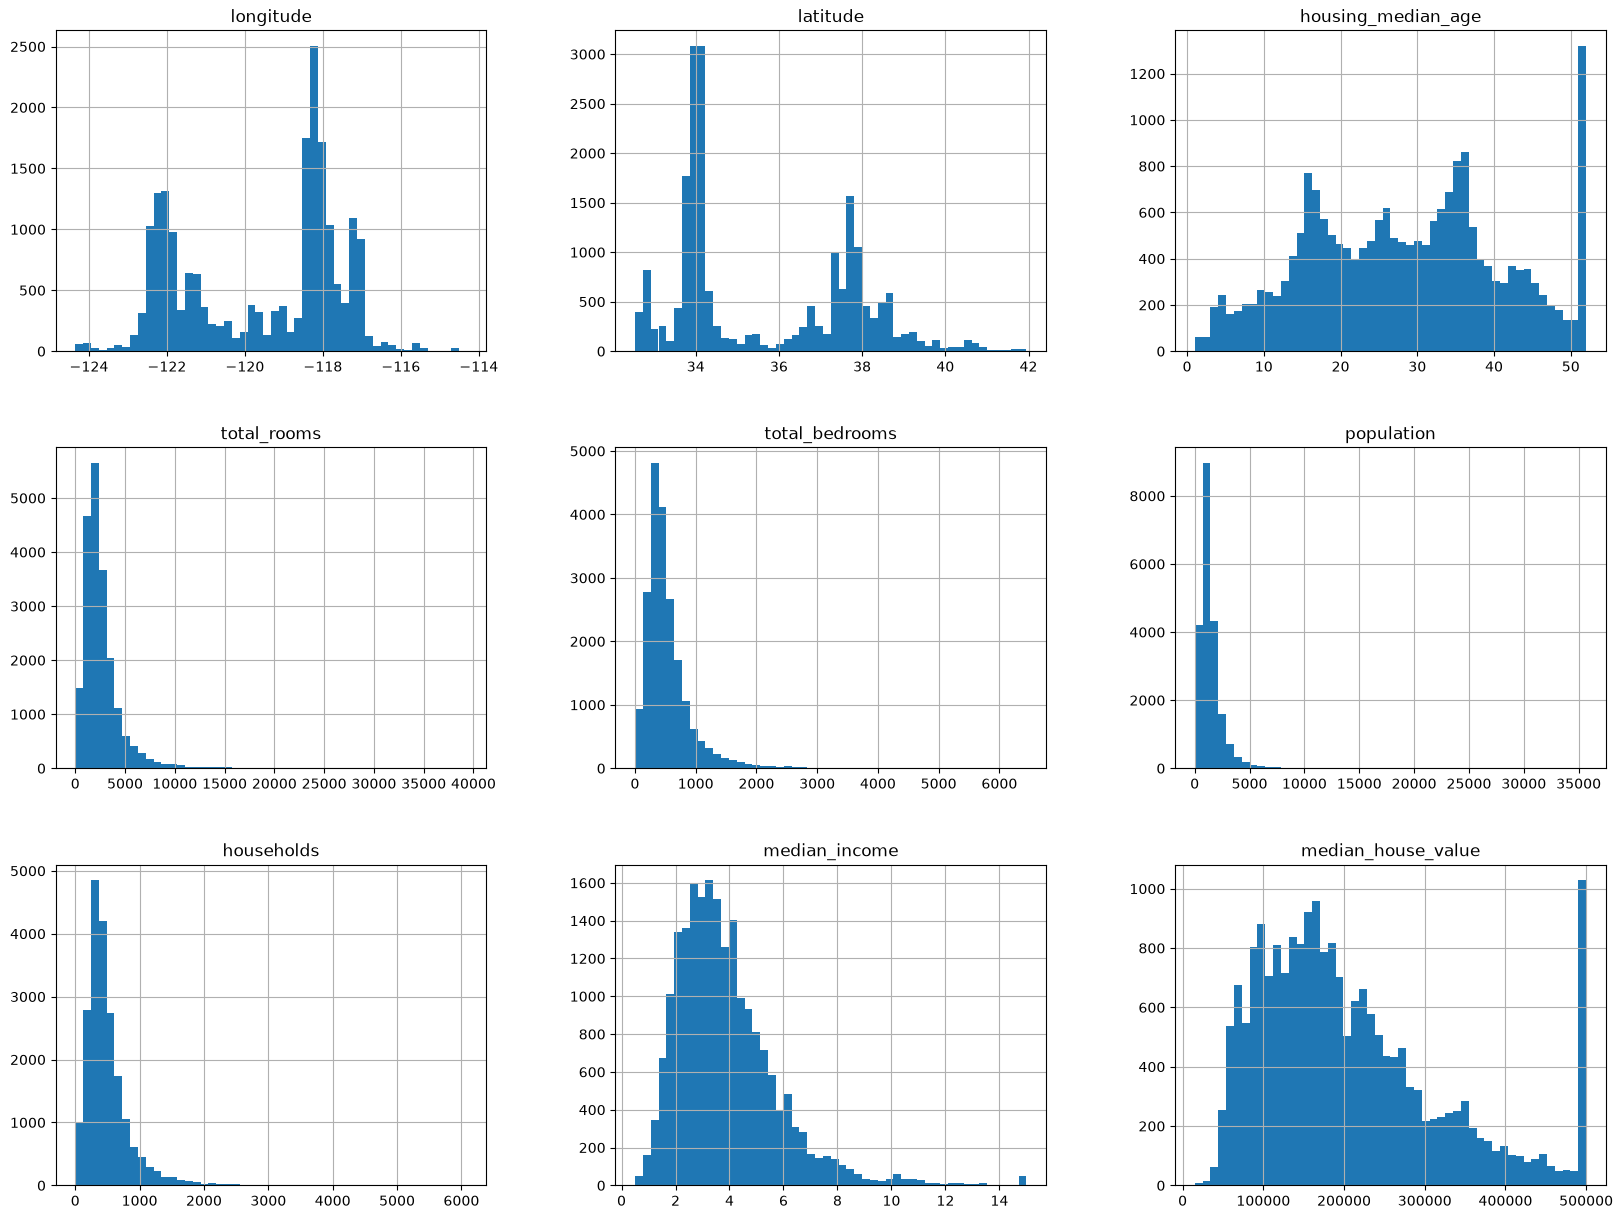

In [6]:
housing.hist(bins=50,figsize=(20,15))

### Create a test set and never look at it again

In [7]:
# make sure the same data is being paced as the test set each time you run the algorithm to avoid data snooping
from zlib import crc32
import numpy as np
def test_set_check(identifier,test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio* 2**32
def split_train_test(data,identifier,test_ratio):
    id_column = data[identifier]
    test_set_id = id_column.apply(test_set_check,test_ratio=test_ratio)
    return data.loc[~test_set_id],data.loc[test_set_id]


In [8]:
# since the dataset we are using doesnt really have an identifier column in it what we can do is to combined some columns to act as a unique identifier or to create a new column.
# example code to create a new column for id.
housing_with_id = housing.reset_index()
train_set,test_set = split_train_test(housing_with_id,"index",0.2)
train_set.head()
test_set.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
5,5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
12,12,-122.26,37.85,52.0,2491.0,474.0,1098.0,468.0,3.0750,213500.0,NEAR BAY
16,16,-122.27,37.85,52.0,1966.0,347.0,793.0,331.0,2.7750,152500.0,NEAR BAY
23,23,-122.27,37.84,52.0,1688.0,337.0,853.0,325.0,2.1806,99700.0,NEAR BAY


In [9]:
# create a identifier column using existing column data
housing_with_id["id"]=housing["latitude"]*1000+housing["longitude"]
train_set, test_set = split_train_test(housing_with_id,"id",0.2)

In [10]:
# split data into train and test set using sklearn
from sklearn.model_selection import train_test_split
train_set ,test_set = train_test_split(housing,test_size=0.2,random_state=42)

In [11]:
housing["income_cat"]=pd.cut(housing["median_income"],bins=[0.,1.5,3.0,4.5,6.0,np.inf],labels=[1,2,3,4,5])

<Axes: >

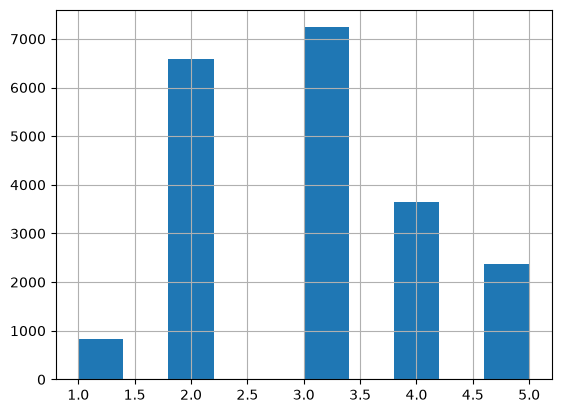

In [12]:
housing["income_cat"].hist()

In [13]:
# make sure that the amount of rows of each cat is perfectly distributed as 80/20 based on income_cat
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index, test_index in split.split(housing,housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [14]:
strat_test_set["income_cat"].value_counts()

income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

In [15]:
# remove the new income category column so that data is back to normal
for set_ in (strat_test_set,strat_train_set):
    set_.drop("income_cat",axis=1,inplace=True)

In [16]:
# store the train set you just created in the original and keep the test set aside 
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

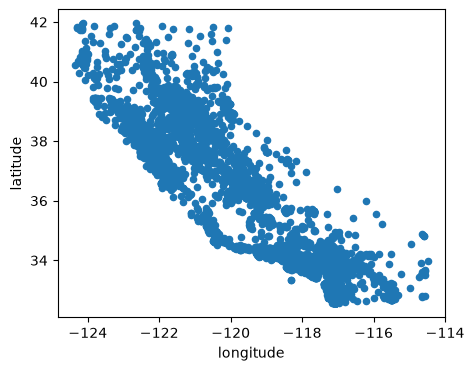

In [17]:
housing.plot(kind="scatter",x="longitude",y="latitude",figsize=(5,4))

<Axes: xlabel='longitude', ylabel='latitude'>

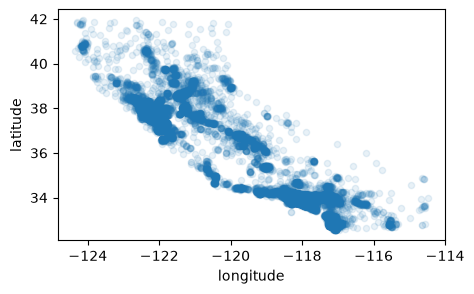

In [18]:
# make dense areas visible 
housing.plot(kind="scatter",x="longitude",y="latitude",figsize=(5,3),alpha=0.1)

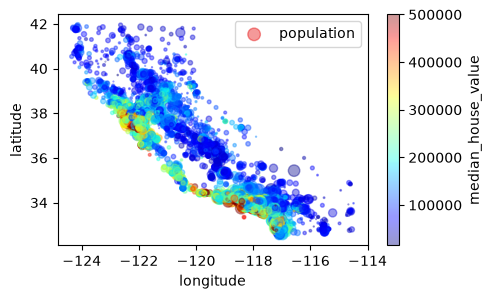

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
 s=housing["population"]/100, label="population", figsize=(5,3),
 c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

In [20]:
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

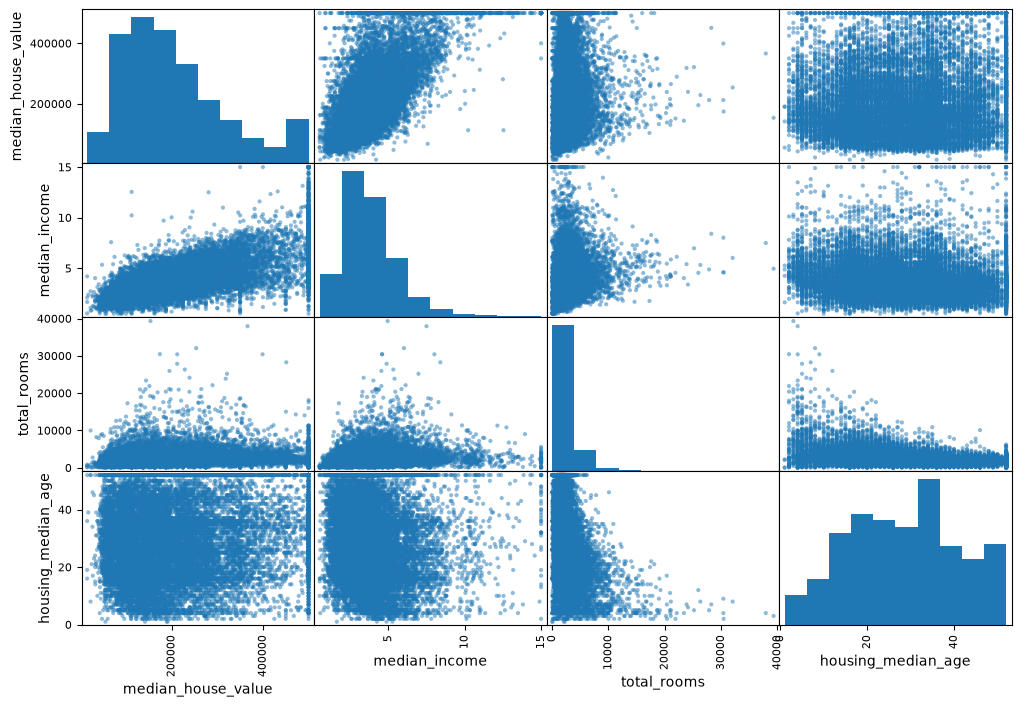

In [21]:
# create a scatter matrix - each feature is mapped against another in a given set
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
 "housing_median_age"]
scatter_matrix(housing[attributes],figsize=(12,8))

In [22]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688380
rooms_per_household         0.143663
total_rooms                 0.137455
housing_median_age          0.102175
households                  0.071426
total_bedrooms              0.054635
population                 -0.020153
population_per_household   -0.038224
longitude                  -0.050859
latitude                   -0.139584
bedrooms_per_room          -0.256397
Name: median_house_value, dtype: float64

In [23]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_label = strat_train_set["median_house_value"].copy()

### Data cleaning

In [24]:
# use imputer to fill missing values with median - this also ensures any future missing values are also covered
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity",axis=1)
imputer.fit(housing_num)
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [25]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [26]:
# since the imputer has learned and memorized the correct medians for the training set we can go on and use this to fill missing nulls 
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X,columns=housing_num.columns,index=housing_num.index)
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292
...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455


In [27]:
housing_cat = housing[["ocean_proximity"]]
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.],
       [0.],
       [0.]])

In [28]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [29]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()
housing_cat_1hot = one_hot_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [30]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

In [31]:
from sklearn.base import BaseEstimator,TransformerMixin
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator,TransformerMixin):
    def __init__(self,add_bedrooms=True):
        self.add_bedrooms=add_bedrooms
    def fit(self,X):
        return self
    def transform(self,X):
        rooms_per_household=X[:,rooms_ix]/X[:,households_ix]
        population_per_household=X[:,population_ix]/X[:,households_ix]
        if self.add_bedrooms:
            bedrooms_per_room=X[:,bedrooms_ix]/X[:,rooms_ix]
            return np.c_[X,rooms_per_household,population_per_household,bedrooms_per_room]
        return np.c_[X,rooms_per_household,population_per_household]
add_attributes = CombinedAttributesAdder(add_bedrooms=False)
housing_extra_attributes=add_attributes.transform(housing.values)
housing_extra_attributes

array([[-122.42, 37.8, 52.0, ..., 'NEAR BAY', 3.211798839458414,
        1.5241779497098646],
       [-118.38, 34.14, 40.0, ..., '<1H OCEAN', 5.504201680672269,
        1.865546218487395],
       [-121.98, 38.36, 33.0, ..., 'INLAND', 5.334975369458128,
        2.768472906403941],
       ...,
       [-117.06, 32.59, 13.0, ..., 'NEAR OCEAN', 5.157894736842105,
        3.7026315789473685],
       [-118.4, 34.06, 37.0, ..., '<1H OCEAN', 4.511933174224343,
        2.058472553699284],
       [-122.41, 37.66, 44.0, ..., 'NEAR OCEAN', 2.0330188679245285,
        3.2169811320754715]], shape=(16512, 11), dtype=object)

### Feature scaling

In [40]:
### using pipline to execute multiple sequential steps
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy="median")),
    ('add_attributes',CombinedAttributesAdder()),
    ('std_scaler',StandardScaler()),
])
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [41]:
housing_num_tr

array([[-1.42303652,  1.0136059 ,  1.86111875, ..., -0.86602737,
        -0.33020372,  1.84662439],
       [ 0.59639445, -0.702103  ,  0.90762971, ...,  0.0245495 ,
        -0.25361631, -0.5081207 ],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.04119332,
        -0.05104091, -0.20215476],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ..., -0.10998748,
         0.15854151, -0.24249175],
       [ 0.58639727, -0.73960483,  0.66925745, ..., -0.36093745,
        -0.21033248,  0.25977479],
       [-1.41803793,  0.94797769,  1.22545939, ..., -1.32397227,
         0.04958379,  3.61270996]], shape=(16512, 11))

In [44]:
from sklearn.compose import ColumnTransformer
num_attributes = list(housing_num) 
cat_attributes = ['ocean_proximity']
full_pipeline = ColumnTransformer([
    ('num',num_pipeline,num_attributes),
    ('cat',OneHotEncoder(),cat_attributes),
])
housing_prepared = full_pipeline.fit_transform(housing)

In [61]:
full_pipeline.named_transformers_["cat"].categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

# Model Training 
## First let's go with linear regression model

In [69]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression() 
lin_reg.fit(housing_prepared,housing_label)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-55577.75,-56704.92, 13153.04,...,194681.24,-43122.1 ,-35911.48]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.575e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[254.23,184.61,173.99,..., 16.08, 1.58, 0. ]"


In [78]:
test_data = housing.iloc[:5]
test_data_labels = housing_label.iloc[:5]
test_data_prepared=full_pipeline.transform(test_data)
predictions =lin_reg.predict(test_data_prepared)
print("Linear Model Prediction : ",predictions) 
print("Actual Labels : ",list(test_data_labels))

Linear Model Prediction :  [276608.27419651 333603.0303772  118237.5726011  108255.75159886
 308943.82732346]
Actual Labels :  [458300.0, 483800.0, 101700.0, 96100.0, 361800.0]


In [81]:
# measure the error 
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test_data_labels,predictions)
rmse = np.sqrt(mse)
rmse

np.float64(108430.66125760402)

In [84]:
# training a decision tree regressor model 
from sklearn.tree import DecisionTreeRegressor
dsc_tree_reg = DecisionTreeRegressor()
dsc_tree_reg.fit(housing_prepared,housing_label)
dsc_pred =dsc_tree_reg.predict(housing_prepared)
tree_mse=mean_squared_error(housing_label,dsc_pred)
print('rmse : ',np.sqrt(tree_mse))

rmse :  0.0


In [87]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(dsc_tree_reg,housing_prepared, housing_label,scoring="neg_mean_squared_error", cv=10)
rmse_Scores=np.sqrt(-scores)

In [93]:
def display_scores(scores):
    print('Scores : ',scores)
    print('Mean : ',scores.mean())
    print('STD deviation : ',scores.std())
display_scores(rmse_Scores)

Scores :  [68262.50657514 66372.83728649 67977.52328793 72989.3089915
 69079.91657625 72017.30544131 72041.19489493 71403.44056873
 69979.97940856 69527.54921081]
Mean :  69965.15622416497
STD deviation :  2011.597363132903


In [94]:
#perform cross validation on linear regression as well
linear_scores=cross_val_score(lin_reg,housing_prepared,housing_label,scoring="neg_mean_squared_error",cv=10) 
display_scores(np.sqrt(-linear_scores))

Scores :  [69717.57852026 66650.26617871 66488.43193213 70478.22519838
 66837.93229332 68220.31091521 66922.70445332 69700.47781664
 67122.26131607 67802.47918508]
Mean :  67994.06678091262
STD deviation :  1394.9377015503228
